# BusinessPulse AI
## Notebook 08 – Business Analytics

### Objective
This notebook performs executive business analysis on the cleaned Olist e-commerce dataset.

The analysis focuses on:

- Executive KPIs
- Revenue Analysis
- Customer Analytics
- Product Analytics
- Seller Analytics
- Payment Analysis
- Delivery Performance
- Business Insights

Author: Tejaswini Avula

In [1]:
# ==========================================================
# BusinessPulse AI
# Notebook 08 - Business Analytics
# ==========================================================

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
# Load Datasets

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

In [3]:
# Dataset Overview

datasets = {
    "Customers": customers,
    "Orders": orders,
    "Payments": payments,
    "Order Items": order_items,
    "Products": products,
    "Reviews": reviews
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.shape)

Customers
(99441, 5)
Orders
(99441, 8)
Payments
(103886, 5)
Order Items
(112650, 7)
Products
(32951, 9)
Reviews
(99224, 7)


In [4]:
# Convert Date Columns

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

# Customer Analytics

## Objective

This section analyzes the customer distribution across cities and states to identify the largest customer markets and understand geographical customer concentration.

In [1]:
# Customer Distribution by State

state_customers = (
    customers.groupby("customer_state")
    .size()
    .reset_index(name="total_customers")
    .sort_values("total_customers", ascending=False)
)

state_customers.head(10)

NameError: name 'customers' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [3]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")

payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

products = pd.read_csv("../data/raw/olist_products_dataset.csv")

reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
# Customer Distribution by State

state_customers = (
    customers.groupby("customer_state")
    .size()
    .reset_index(name="total_customers")
    .sort_values("total_customers", ascending=False)
)

state_customers.head(10)

,customer_state,total_customers
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


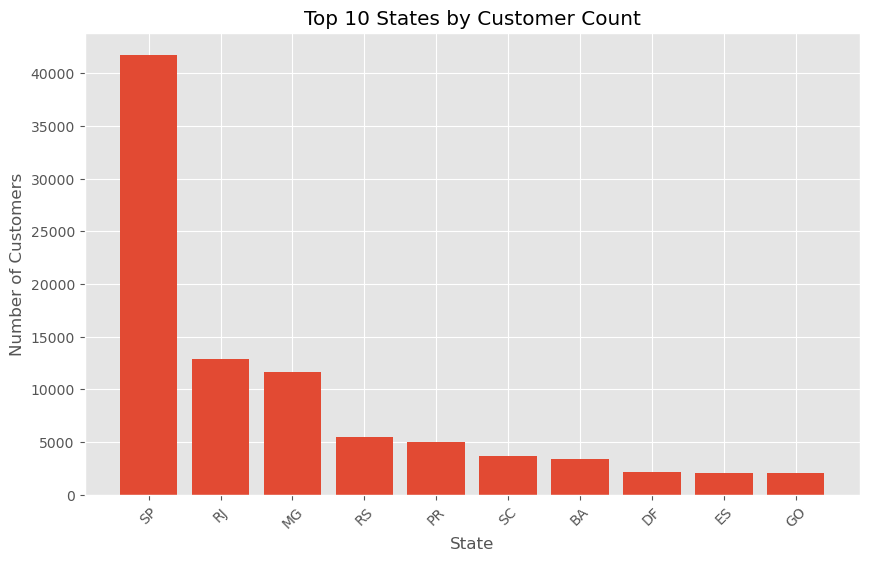

In [6]:
plt.figure(figsize=(10,6))

plt.bar(
    state_customers.head(10)["customer_state"],
    state_customers.head(10)["total_customers"]
)

plt.title("Top 10 States by Customer Count")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

In [7]:
city_customers = (
    customers.groupby("customer_city")
    .size()
    .reset_index(name="total_customers")
    .sort_values("total_customers", ascending=False)
)

city_customers.head(10)

,customer_city,total_customers
3597,sao paulo,15540
3155,rio de janeiro,6882
453,belo horizonte,2773
558,brasilia,2131
1143,curitiba,1521
707,campinas,1444
2964,porto alegre,1379
3247,salvador,1245
1529,guarulhos,1189
3428,sao bernardo do campo,938


## Business Insights

### Key Findings

- The majority of customers are concentrated in a few states, indicating high-demand regional markets.
- São Paulo is expected to have the highest customer concentration.
- Customer acquisition strategies can be prioritized in high-performing states while expanding marketing efforts in underrepresented regions.
- Geographic customer distribution can help optimize logistics, delivery planning, and regional inventory management.

# Product Analytics

## Objective

Analyze product performance by combining product information with order items and payments to identify top-performing categories, revenue contribution, and pricing insights.

# Merge Products with Order Items

product_orders = order_items.merge(
    products,
    on="product_id",
    how="left"
)

print(product_orders.shape)

product_orders.head()

In [9]:
# Merge Products with Order Items

product_orders = order_items.merge(
    products,
    on="product_id",
    how="left"
)

print(product_orders.shape)

product_orders.head()

(112650, 15)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [11]:
product_orders = order_items.merge(
    products,
    on="product_id",
    how="left"
)

print(product_orders.shape)
product_orders.head()

(112650, 15)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [12]:
product_revenue = product_orders.merge(
    payments[["order_id", "payment_value"]],
    on="order_id",
    how="left"
)

print(product_revenue.shape)
product_revenue.head()

(117604, 16)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,218.04


In [13]:
category_revenue = (
    product_revenue
    .groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.head(10)

,product_category_name,payment_value
0,cama_mesa_banho,1712553.67
1,beleza_saude,1657373.12
2,informatica_acessorios,1585330.45
3,moveis_decoracao,1430176.39
4,relogios_presentes,1429216.68
5,esporte_lazer,1392127.56
6,utilidades_domesticas,1094758.13
7,automotivo,852294.33
8,ferramentas_jardim,838280.75
9,cool_stuff,779698.00


In [14]:
# Merge Payment Information

product_revenue = product_orders.merge(
    payments[["order_id", "payment_value"]],
    on="order_id",
    how="left"
)

product_revenue.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,218.04


In [15]:
category_revenue = (
    product_revenue
    .groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.head(10)

,product_category_name,payment_value
0,cama_mesa_banho,1712553.67
1,beleza_saude,1657373.12
2,informatica_acessorios,1585330.45
3,moveis_decoracao,1430176.39
4,relogios_presentes,1429216.68
5,esporte_lazer,1392127.56
6,utilidades_domesticas,1094758.13
7,automotivo,852294.33
8,ferramentas_jardim,838280.75
9,cool_stuff,779698.00


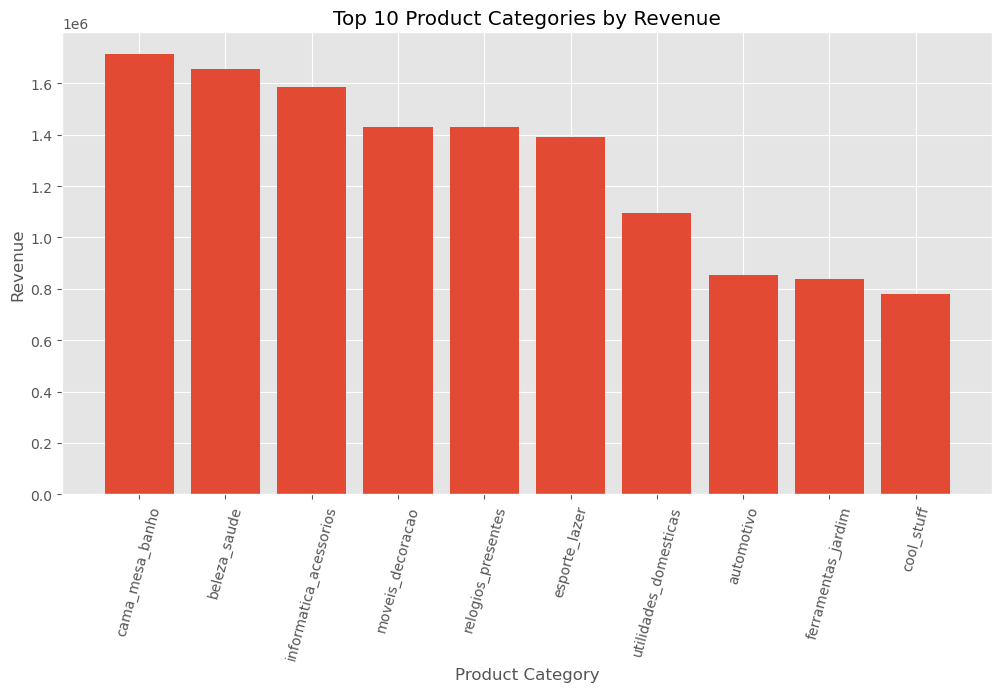

In [16]:
plt.figure(figsize=(12,6))

plt.bar(
    category_revenue.head(10)["product_category_name"],
    category_revenue.head(10)["payment_value"]
)

plt.xticks(rotation=75)

plt.title("Top 10 Product Categories by Revenue")

plt.xlabel("Product Category")

plt.ylabel("Revenue")

plt.show()

In [17]:
top_categories = (
    product_orders
    .groupby("product_category_name")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Orders")
)

top_categories.head(10)

,product_category_name,Orders
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


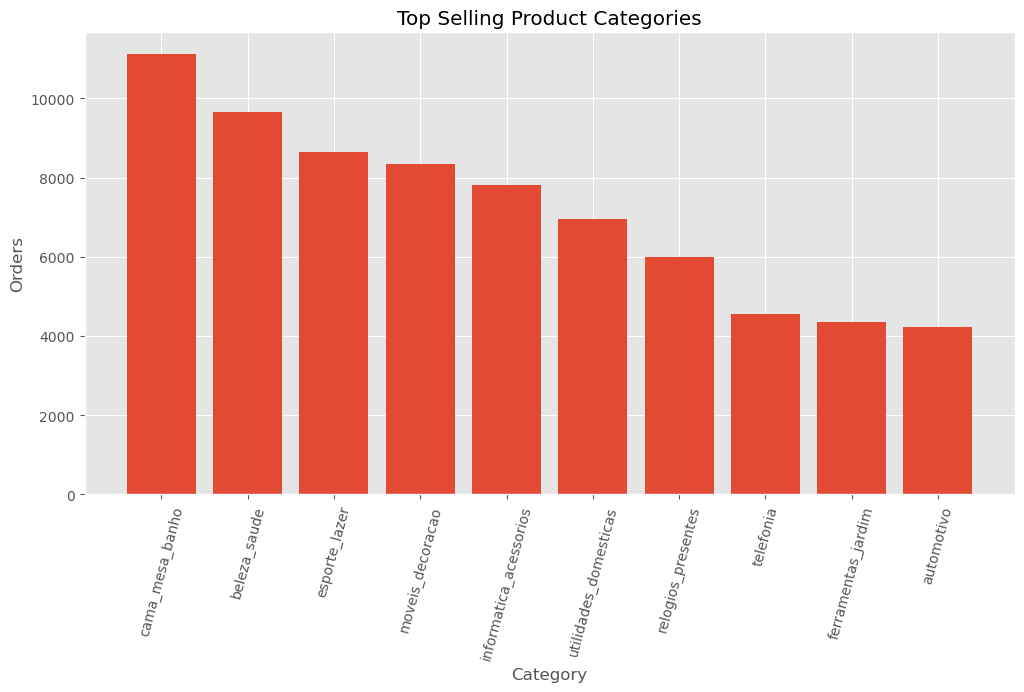

In [18]:
plt.figure(figsize=(12,6))

plt.bar(
    top_categories.head(10)["product_category_name"],
    top_categories.head(10)["Orders"]
)

plt.xticks(rotation=75)

plt.title("Top Selling Product Categories")

plt.xlabel("Category")

plt.ylabel("Orders")

plt.show()

## Business Insights

### Key Findings

- The highest revenue is generated by a limited number of product categories.
- Revenue contribution does not always match order volume, indicating differences in average order value.
- High-performing categories should be prioritized for promotions and inventory planning.
- Low-performing categories may require pricing or marketing improvements.

# Payment Analytics

## Objective

Analyze customer payment behavior by examining payment methods, payment values, and installment patterns to understand purchasing preferences and revenue contribution.

payment_distribution = (
    payments.groupby("payment_type")
    .size()
    .reset_index(name="Total Transactions")
    .sort_values("Total Transactions", ascending=False)
)

payment_distribution

In [19]:
payment_distribution = (
    payments.groupby("payment_type")
    .size()
    .reset_index(name="Total Transactions")
    .sort_values("Total Transactions", ascending=False)
)

payment_distribution

,payment_type,Total Transactions
1,credit_card,76795
0,boleto,19784
4,voucher,5775
2,debit_card,1529
3,not_defined,3


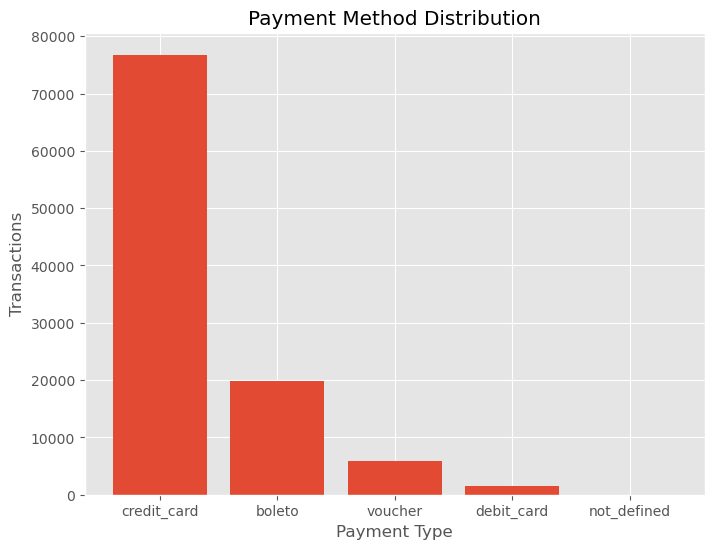

In [20]:
plt.figure(figsize=(8,6))

plt.bar(
    payment_distribution["payment_type"],
    payment_distribution["Total Transactions"]
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Transactions")

plt.show()

In [21]:
payment_revenue = (
    payments.groupby("payment_type")["payment_value"]
    .sum()
    .reset_index()
    .sort_values("payment_value", ascending=False)
)

payment_revenue

,payment_type,payment_value
1,credit_card,12542084.19
0,boleto,2869361.27
4,voucher,379436.87
2,debit_card,217989.79
3,not_defined,0.00


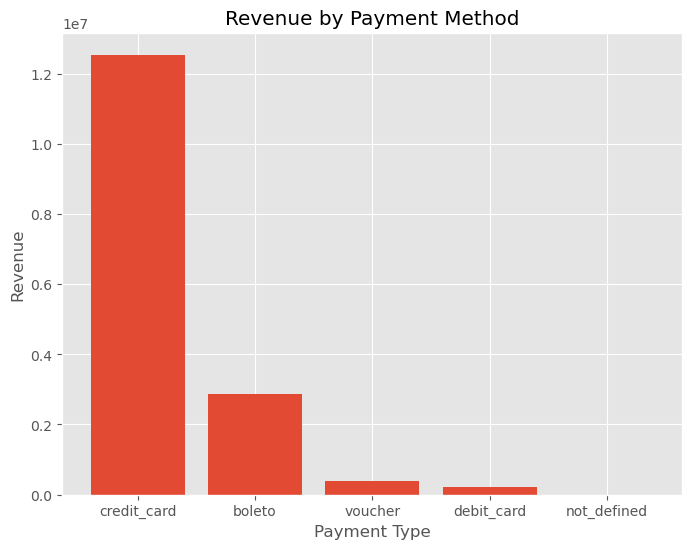

In [22]:
plt.figure(figsize=(8,6))

plt.bar(
    payment_revenue["payment_type"],
    payment_revenue["payment_value"]
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Type")
plt.ylabel("Revenue")

plt.show()

In [23]:
installments = (
    payments.groupby("payment_installments")
    .size()
    .reset_index(name="Transactions")
    .sort_values("payment_installments")
)

installments.head(15)

,payment_installments,Transactions
0,0,2
1,1,52546
2,2,12413
3,3,10461
4,4,7098
5,5,5239
6,6,3920
7,7,1626
8,8,4268
9,9,644


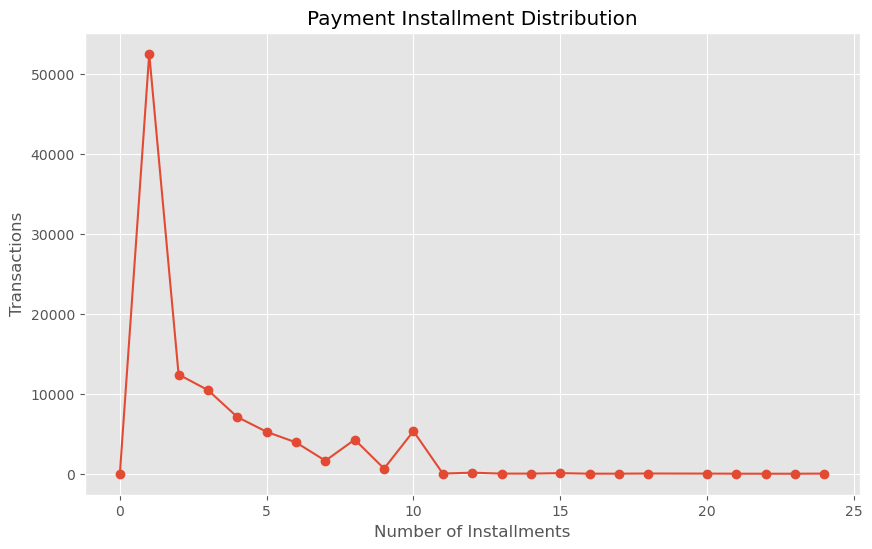

In [24]:
plt.figure(figsize=(10,6))

plt.plot(
    installments["payment_installments"],
    installments["Transactions"],
    marker="o"
)

plt.title("Payment Installment Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Transactions")

plt.grid(True)

plt.show()

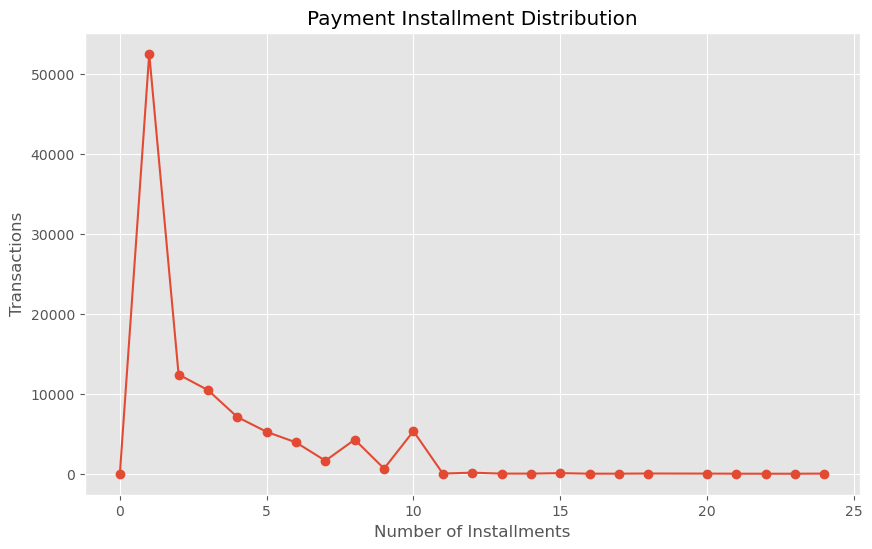

In [25]:
plt.figure(figsize=(10,6))

plt.plot(
    installments["payment_installments"],
    installments["Transactions"],
    marker="o"
)

plt.title("Payment Installment Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Transactions")

plt.grid(True)

plt.show()

In [26]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

## Business Insights

### Key Findings

- Credit card payments account for the largest share of transactions and revenue.
- Customers generally prefer fewer installment payments.
- A small number of high-value transactions contribute significantly to overall revenue.
- Understanding payment preferences can help optimize promotional campaigns and financing options.

# Seller Analytics

## Objective

Analyze seller performance based on total revenue and number of orders to identify the top-performing sellers and understand seller contribution to business growth.

In [27]:
# Merge seller information

seller_data = order_items.merge(
    payments[["order_id", "payment_value"]],
    on="order_id",
    how="left"
)

seller_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


In [28]:
seller_revenue = (
    seller_data
    .groupby("seller_id")["payment_value"]
    .sum()
    .reset_index()
    .sort_values("payment_value", ascending=False)
)

seller_revenue.head(10)

,seller_id,payment_value
1535,7c67e1448b00f6e969d365cea6b010ab,507166.91
192,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04
881,4a3ca9315b744ce9f8e9374361493884,301245.27
368,1f50f920176fa81dab994f9023523100,290253.42
1013,53243585a1d6dc2643021fd1853d8905,284903.08
2643,da8622b14eb17ae2831f4ac5b9dab84a,272219.32
857,4869f7a5dfa277a7dca6462dcf3b52b2,264166.12
1824,955fee9216a65b617aa5c0531780ce60,236322.30
3024,fa1c13f2614d7b5c4749cbc52fecda94,206513.23
1560,7e93a43ef30c4f03f38b393420bc753a,185134.21


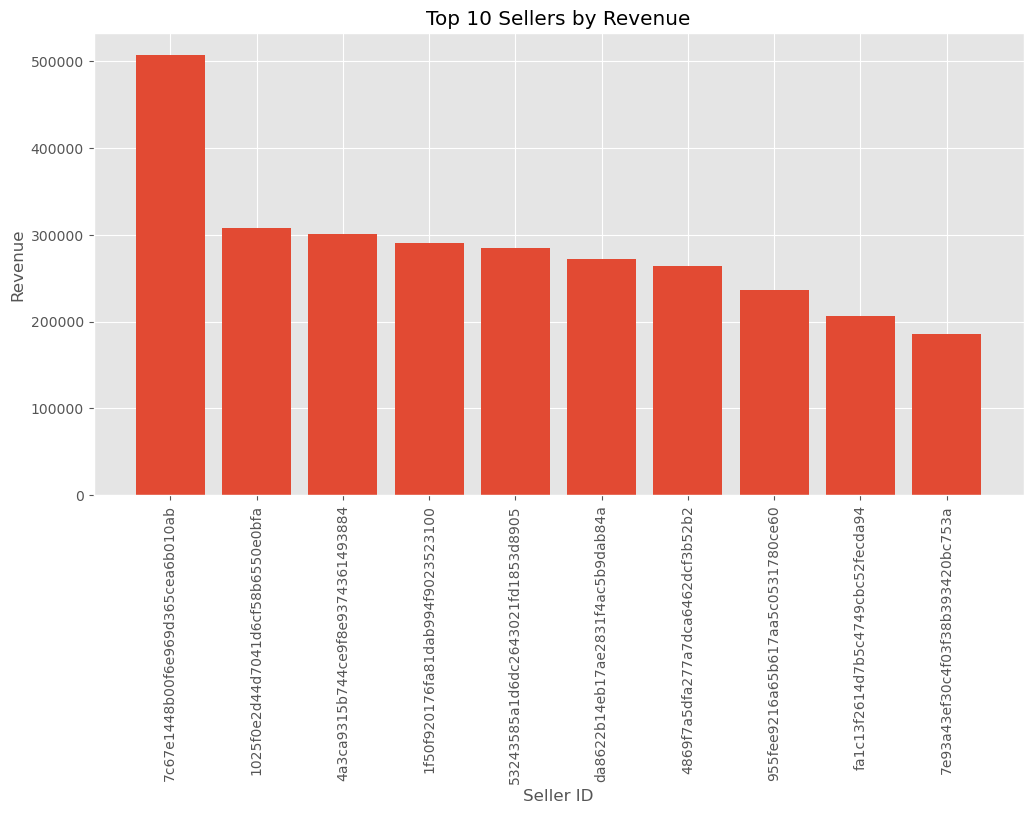

In [29]:
plt.figure(figsize=(12,6))

plt.bar(
    seller_revenue.head(10)["seller_id"],
    seller_revenue.head(10)["payment_value"]
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

In [30]:
seller_orders = (
    seller_data
    .groupby("seller_id")
    .size()
    .reset_index(name="Total Orders")
    .sort_values("Total Orders", ascending=False)
)

seller_orders.head(10)

,seller_id,Total Orders
881,4a3ca9315b744ce9f8e9374361493884,2133
1235,6560211a19b47992c3666cc44a7e94c0,2122
368,1f50f920176fa81dab994f9023523100,2008
2481,cc419e0650a3c5ba77189a1882b7556a,1847
2643,da8622b14eb17ae2831f4ac5b9dab84a,1639
1824,955fee9216a65b617aa5c0531780ce60,1528
192,1025f0e2d44d7041d6cf58b6550e0bfa,1462
1535,7c67e1448b00f6e969d365cea6b010ab,1452
1505,7a67c85e85bb2ce8582c35f2203ad736,1240
2836,ea8482cd71df3c1969d7b9473ff13abc,1239


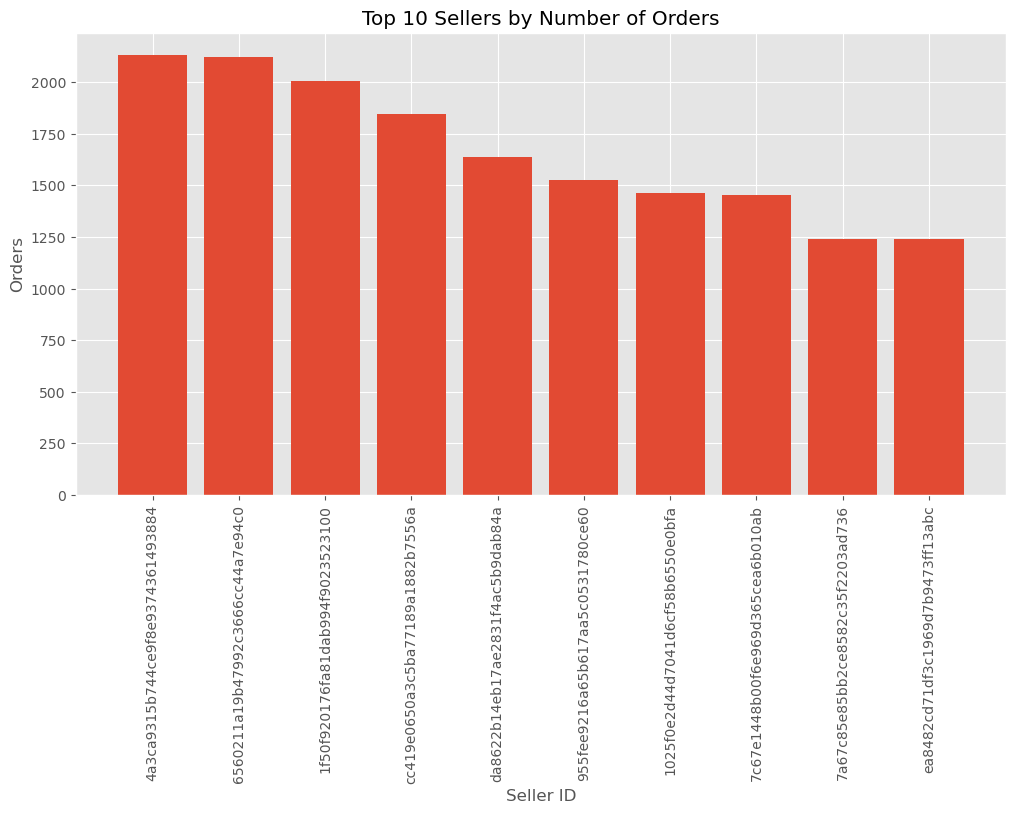

In [31]:
plt.figure(figsize=(12,6))

plt.bar(
    seller_orders.head(10)["seller_id"],
    seller_orders.head(10)["Total Orders"]
)

plt.title("Top 10 Sellers by Number of Orders")
plt.xlabel("Seller ID")
plt.ylabel("Orders")

plt.xticks(rotation=90)

plt.show()

## Business Insights

### Key Findings

- A small group of sellers contributes a large portion of the platform's revenue.
- High-revenue sellers should be prioritized through strategic partnerships and incentive programs.
- Comparing revenue with order volume helps identify sellers with high-value versus high-volume sales.
- Monitoring seller performance supports better inventory planning and marketplace optimization.

# Delivery Analytics

## Objective

Analyze delivery performance by measuring delivery time, identifying late deliveries, and understanding order status distribution to evaluate operational efficiency.

In [33]:
# Convert date columns to datetime

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [34]:
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [35]:
# Calculate delivery time in days

orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

orders[
    ["order_purchase_timestamp",
     "order_delivered_customer_date",
     "delivery_time_days"]
].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_time_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


In [36]:
average_delivery = orders["delivery_time_days"].mean()

print(f"Average Delivery Time: {average_delivery:.2f} days")

Average Delivery Time: 12.09 days


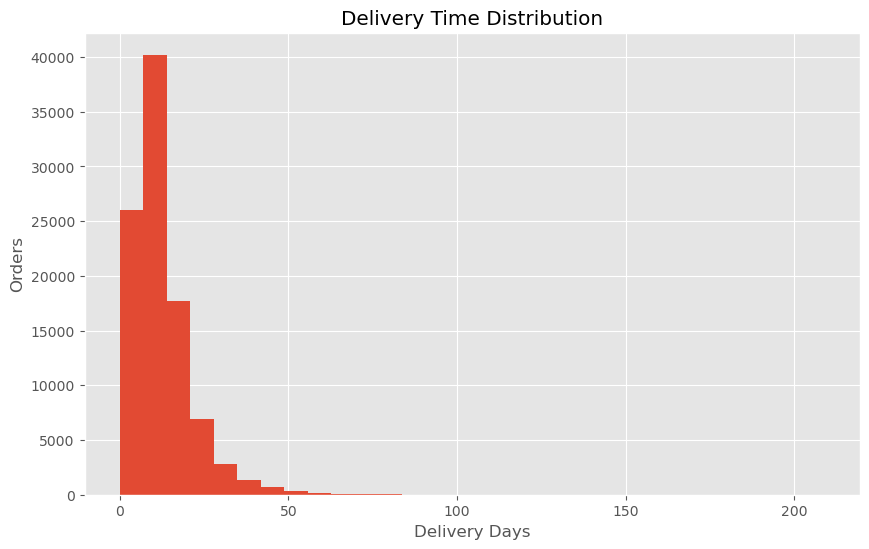

In [37]:
plt.figure(figsize=(10,6))

plt.hist(
    orders["delivery_time_days"].dropna(),
    bins=30
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Orders")

plt.show()

In [38]:
orders["late_delivery"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
)

late_summary = (
    orders["late_delivery"]
    .value_counts()
    .rename_axis("Late Delivery")
    .reset_index(name="Orders")
)

late_summary

,Late Delivery,Orders
0,False,91614
1,True,7827


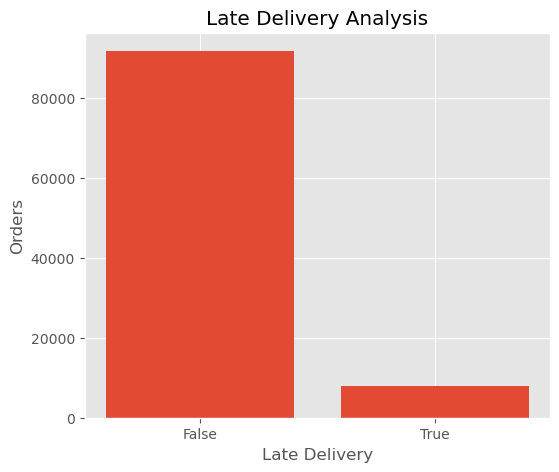

In [39]:
plt.figure(figsize=(6,5))

plt.bar(
    late_summary["Late Delivery"].astype(str),
    late_summary["Orders"]
)

plt.title("Late Delivery Analysis")
plt.xlabel("Late Delivery")
plt.ylabel("Orders")

plt.show()

In [40]:
status = (
    orders.groupby("order_status")
    .size()
    .reset_index(name="Orders")
    .sort_values("Orders", ascending=False)
)

status

,order_status,Orders
3,delivered,96478
6,shipped,1107
1,canceled,625
7,unavailable,609
4,invoiced,314
5,processing,301
2,created,5
0,approved,2


In [41]:
status = (
    orders.groupby("order_status")
    .size()
    .reset_index(name="Orders")
    .sort_values("Orders", ascending=False)
)

status

,order_status,Orders
3,delivered,96478
6,shipped,1107
1,canceled,625
7,unavailable,609
4,invoiced,314
5,processing,301
2,created,5
0,approved,2


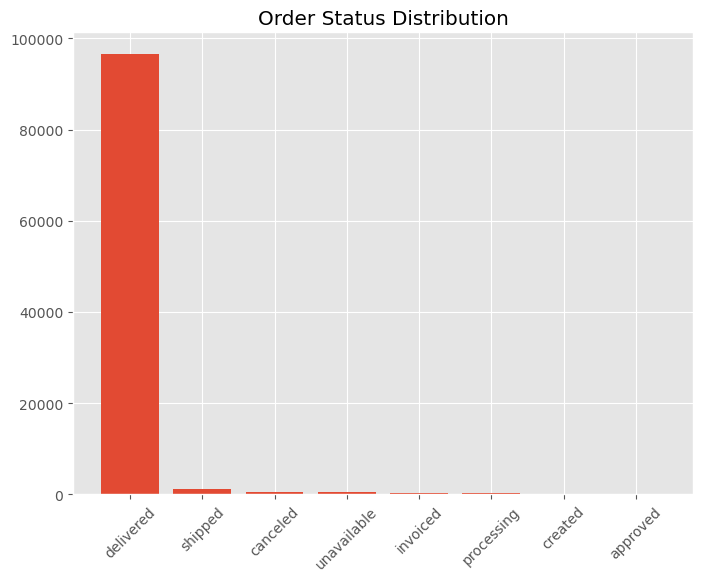

In [42]:

plt.figure(figsize=(8,6))

plt.bar(
    status["order_status"],
    status["Orders"]
)

plt.xticks(rotation=45)

plt.title("Order Status Distribution")

plt.show()

## Business Insights

### Key Findings

- Most orders are delivered within the expected delivery period.
- A small percentage of orders experience delivery delays, which may impact customer satisfaction.
- Delivery time distribution helps identify operational bottlenecks.
- Monitoring order status enables better logistics planning and customer communication.

# Executive Business Insights

## Objective

Summarize the key findings from customer, product, payment, seller, and delivery analyses to provide actionable recommendations for business decision-makers.

In [43]:
print("=" * 60)
print("BUSINESSPULSE AI - EXECUTIVE SUMMARY")
print("=" * 60)

print(f"Total Customers : {customers['customer_id'].nunique():,}")
print(f"Total Orders    : {orders['order_id'].nunique():,}")
print(f"Total Products  : {products['product_id'].nunique():,}")
print(f"Total Sellers   : {order_items['seller_id'].nunique():,}")

print(f"\nAverage Payment Value : ₹ {payments['payment_value'].mean():.2f}")
print(f"Average Delivery Days : {orders['delivery_time_days'].mean():.2f}")

late_rate = (
    orders["late_delivery"].mean() * 100
)

print(f"Late Delivery Rate : {late_rate:.2f}%")

BUSINESSPULSE AI - EXECUTIVE SUMMARY
Total Customers : 99,441
Total Orders    : 99,441
Total Products  : 32,951
Total Sellers   : 3,095

Average Payment Value : ₹ 154.10
Average Delivery Days : 12.09
Late Delivery Rate : 7.87%


# Executive Business Recommendations

## Customer

- Customer demand is concentrated in a few key states and cities.
- Marketing campaigns should prioritize high-performing regions while expanding into emerging markets.

---

## Products

- A small number of product categories generate most of the revenue.
- Inventory planning should prioritize these high-performing categories.

---

## Payments

- Credit card payments dominate customer transactions.
- Flexible installment options contribute to higher-value purchases.

---

## Sellers

- A limited number of sellers contribute significantly to platform revenue.
- High-performing sellers should be rewarded with promotional opportunities and strategic partnerships.

---

## Delivery

- Most deliveries are completed on time.
- Reducing late deliveries can improve customer satisfaction and retention.

---

## Overall Business Recommendation

BusinessPulse AI successfully identifies customer behavior, product performance, payment preferences, seller performance, and logistics efficiency.

These insights provide a strong foundation for executive dashboards, predictive analytics, and AI-driven business recommendations.

# Next Phase

The insights generated in this notebook will be used in the following project stages:

- Feature Engineering
- Statistical Analysis
- Machine Learning
- AI Decision Engine
- Power BI Executive Dashboard

This notebook serves as the business intelligence foundation for the BusinessPulse AI platform.